<a href="https://colab.research.google.com/github/AnishD554/atmospheric-circulation-1979-2025/blob/main/hadley_cell_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install -U cdsapi


In [ ]:
%%writefile ~/.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: e5f66fc4-2da6-47d6-a352-07160a3cbd03

Writing /root/.cdsapirc


In [ ]:
!cat ~/.cdsapirc


url: https://cds.climate.copernicus.eu/api
key: e5f66fc4-2da6-47d6-a352-07160a3cbd03


In [ ]:
import cdsapi

c = cdsapi.Client()

dataset = "reanalysis-era5-single-levels-monthly-means"

request = {
    "product_type": "monthly_averaged_reanalysis",
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind"
    ],
    "year": [str(y) for y in range(1990, 2026)],  # 1990–2025 inclusive
    "month": [f"{m:02d}" for m in range(1, 13)],
    "time": "00:00",
    "format": "netcdf",
}

target = "era5_u10_v10_monthly_1990_2025.nc"

c.retrieve(dataset, request, target)
print("Saved:", target)


2026-02-21 22:54:02,693 INFO Request ID is 5abe6978-471f-4e9c-bd83-83ff68363043
INFO:ecmwf.datastores.legacy_client:Request ID is 5abe6978-471f-4e9c-bd83-83ff68363043
2026-02-21 22:54:02,855 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-02-21 22:54:08,405 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running


KeyboardInterrupt: 

In [ ]:
import xarray as xr

ds = xr.open_dataset("era5_u10_v10_monthly_1990_2025.nc", decode_times=True)
print(ds)
print("coords:", list(ds.coords))
print("dims:", dict(ds.dims))


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/era5_u10_v10_monthly_1990_2025.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("era5_u10_v10_monthly_1990_2025.nc", decode_times=True)

# Find a time coordinate
time_candidates = ["time", "valid_time", "date", "datetime", "forecast_reference_time"]
time_name = None
for c in time_candidates:
    if c in ds.coords:
        time_name = c
        break

if time_name is None:
    # sometimes time exists as a variable, not a coord
    for v in time_candidates:
        if v in ds.variables and v in ds.dims:
            time_name = v
            break

if time_name is None:
    raise ValueError(f"No time coordinate found. Coords={list(ds.coords)} Vars={list(ds.variables)}")

if time_name != "time":
    ds = ds.rename({time_name: "time"})

# Ensure datetime type (in case it's numeric)
if not np.issubdtype(ds["time"].dtype, np.datetime64):
    ds = xr.decode_cf(ds)

print("Using time coord:", "time", ds["time"].values[:3], "...")


In [ ]:
# ============================================================
# Hadley cell "width" proxy from ERA5 (1990–2025)
# Proxy definition:
#   Hadley edge latitude = latitude (NH/SH) where zonal-mean
#   annual-mean u10 crosses 0 m/s (trade winds -> westerlies)
#
# Data source: ERA5 monthly means (single levels), via CDS API.
# ============================================================

import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) USER SETTINGS
# ----------------------------
START_YEAR = 1990
END_YEAR = 2025

# where to save the downloaded NetCDF
OUTFILE = f"era5_u10_v10_monthly_{START_YEAR}_{END_YEAR}.nc"

# If you only want u10, you can set VARIABLES = ["10m_u_component_of_wind"]
VARIABLES = ["10m_u_component_of_wind", "10m_v_component_of_wind"]

# Latitude search windows (deg) for the subtropical edge
NH_SEARCH = (5, 45)     # look poleward from 5°N to 45°N
SH_SEARCH = (-45, -5)   # look poleward from 5°S to 45°S

# ----------------------------
# 1) DOWNLOAD ERA5 (monthly means) FROM CDS
# ----------------------------
def download_era5_monthly_means(outfile: str):
    """
    Downloads ERA5 monthly means for u10/v10 from CDS.
    Requires:
      pip install cdsapi
      and a valid ~/.cdsapirc (CDS key).
    """
    if os.path.exists(outfile):
        print(f"[OK] Found existing file: {outfile}")
        return

    import cdsapi

    c = cdsapi.Client()

    years = [str(y) for y in range(START_YEAR, END_YEAR + 1)]
    months = [f"{m:02d}" for m in range(1, 13)]
    times = ["00:00"]  # monthly means are time-stamped, 00:00 is fine

    print("[INFO] Requesting ERA5 monthly means from CDS...")
    c.retrieve(
        "reanalysis-era5-single-levels-monthly-means",
        {
            "product_type": "monthly_averaged_reanalysis",
            "format": "netcdf",
            "variable": VARIABLES,
            "year": years,
            "month": months,
            "time": times,
        },
        outfile,
    )
    print(f"[DONE] Saved: {outfile}")


download_era5_monthly_means(OUTFILE)

# ----------------------------
# 2) LOAD + STANDARDIZE VARIABLE NAMES
# ----------------------------
ds = xr.open_dataset(OUTFILE)

# ERA5 CDS names -> tutorial-like names (u10, v10)
rename_map = {}
if "u10" not in ds.data_vars and "10m_u_component_of_wind" in ds.data_vars:
    rename_map["10m_u_component_of_wind"] = "u10"
if "v10" not in ds.data_vars and "10m_v_component_of_wind" in ds.data_vars:
    rename_map["10m_v_component_of_wind"] = "v10"

ds = ds.rename(rename_map)

# Ensure latitude is ascending for consistent interpolation/search
if ds.latitude.values[0] > ds.latitude.values[-1]:
    ds = ds.sortby("latitude")

# ----------------------------
# 3) COMPUTE ANNUAL MEAN ZONAL-MEAN u10(lat, year)
# ----------------------------
# zonal mean over longitude
u_zonal = ds["u10"].mean("longitude")

# annual mean over months
u_ann = u_zonal.groupby("time.year").mean("time")  # dims: (year, latitude)

# ----------------------------
# 4) FIND ZERO-CROSSING = HADLEY EDGE (NH + SH) PER YEAR
# ----------------------------
def zero_crossing_lat(lat: np.ndarray, u: np.ndarray) -> float:
    """
    Find the first latitude where u crosses from negative to positive (u<0 -> u>0).
    Uses linear interpolation between the bracketing grid points.
    Returns NaN if no crossing is found.
    """
    # we want sign change from - to +
    sign = np.sign(u)
    # indices where sign changes
    idx = np.where((sign[:-1] < 0) & (sign[1:] > 0))[0]
    if len(idx) == 0:
        return np.nan

    i = idx[0]
    # linear interpolation: u = u0 + (u1-u0)*t, find t where u=0
    u0, u1 = u[i], u[i + 1]
    lat0, lat1 = lat[i], lat[i + 1]
    t = -u0 / (u1 - u0)
    return float(lat0 + t * (lat1 - lat0))


def hadley_edge_for_year(u_ann_one_year: xr.DataArray, search_bounds: tuple[float, float]) -> float:
    """Compute edge latitude for one year in a given hemisphere search window."""
    lat_min, lat_max = search_bounds
    sub = u_ann_one_year.sel(latitude=slice(lat_min, lat_max))
    lat = sub.latitude.values
    u = sub.values
    return zero_crossing_lat(lat, u)


years = u_ann["year"].values

nh_edge = []
sh_edge = []
for y in years:
    u_y = u_ann.sel(year=y)
    nh_edge.append(hadley_edge_for_year(u_y, NH_SEARCH))
    sh_edge.append(hadley_edge_for_year(u_y, SH_SEARCH))

edges = pd.DataFrame(
    {
        "year": years.astype(int),
        "hadley_edge_NH_deg": nh_edge,
        "hadley_edge_SH_deg": sh_edge,
    }
)

# Optional: define "width" as NH_edge - SH_edge (a positive number, degrees latitude)
edges["hadley_width_deg"] = edges["hadley_edge_NH_deg"] - edges["hadley_edge_SH_deg"]

display(edges.head())

# ----------------------------
# 5) LINEAR TREND (deg / decade)
# ----------------------------
def linear_trend_deg_per_decade(x_year: np.ndarray, y: np.ndarray):
    """Return slope in deg/decade and intercept, using ordinary least squares."""
    mask = np.isfinite(y)
    x = x_year[mask].astype(float)
    yy = y[mask].astype(float)
    if len(x) < 5:
        return np.nan, np.nan

    # Fit y = a*x + b
    a, b = np.polyfit(x, yy, 1)
    return a * 10.0, b  # convert deg/year -> deg/decade


nh_slope_dec, _ = linear_trend_deg_per_decade(edges["year"].values, edges["hadley_edge_NH_deg"].values)
sh_slope_dec, _ = linear_trend_deg_per_decade(edges["year"].values, edges["hadley_edge_SH_deg"].values)
w_slope_dec, _  = linear_trend_deg_per_decade(edges["year"].values, edges["hadley_width_deg"].values)

print(f"NH edge trend:   {nh_slope_dec:.3f} deg/decade")
print(f"SH edge trend:   {sh_slope_dec:.3f} deg/decade")
print(f"Width trend:     {w_slope_dec:.3f} deg/decade")
# ----------------------------
# 6) PLOTS
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(edges["year"], edges["hadley_edge_NH_deg"], label="NH edge (u10=0 crossing)")
ax.plot(edges["year"], edges["hadley_edge_SH_deg"], label="SH edge (u10=0 crossing)")
ax.set_title("Hadley edge proxy from ERA5 monthly mean u10 (annual zonal mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Latitude (deg)")
ax.axhline(0, color="black", alpha=0.2)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(edges["year"], edges["hadley_width_deg"], label="Width = NH_edge - SH_edge")
ax.set_title("Hadley width proxy (degrees latitude)")
ax.set_xlabel("Year")
ax.set_ylabel("Degrees latitude")
ax.legend()
plt.show()


In [ ]:
# ============================================================
# Hadley Cell "Expansion" Proxy from ERA5 (1990–2025)
# Uses ERA5 monthly mean 10m zonal wind (u10).
#
# Proxy:
#   Hadley edge latitude = latitude where zonal-mean annual-mean u10 crosses 0
#   (trade-wind easterlies <0 to westerlies >0). We allow either crossing direction
#   because the sign pattern can differ by hemisphere and data quirks.
#
# Output:
#   - NH edge, SH edge, width = NH - SH (deg latitude)
#   - Trends in deg/decade
#   - Plots
#
# Assumes you already downloaded: era5_u10_v10_monthly_1990_2025.nc
# and that it has dims: valid_time, latitude, longitude (as you showed).
# ============================================================

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE = "era5_u10_v10_monthly_1990_2025.nc"
START_YEAR, END_YEAR = 1990, 2025

# Search windows (degrees)
NH_SEARCH = (5, 45)
SH_SEARCH = (-45, -5)

# ------------------------------------------------------------
# 1) LOAD + STANDARDIZE COORD/VARNAMES
# ------------------------------------------------------------
ds = xr.open_dataset(FILE)

# rename time dimension if needed
if "valid_time" in ds.dims and "time" not in ds.dims:
    ds = ds.rename({"valid_time": "time"})

# rename variable if needed
if "u10" not in ds.data_vars and "10m_u_component_of_wind" in ds.data_vars:
    ds = ds.rename({"10m_u_component_of_wind": "u10"})
if "v10" not in ds.data_vars and "10m_v_component_of_wind" in ds.data_vars:
    ds = ds.rename({"10m_v_component_of_wind": "v10"})

# sort latitude ascending (important for slices + interpolation)
if ds.latitude.values[0] > ds.latitude.values[-1]:
    ds = ds.sortby("latitude")

# restrict time range explicitly
ds = ds.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))

print(ds)

# ------------------------------------------------------------
# 2) ANNUAL ZONAL MEAN u10(lat, year)
# ------------------------------------------------------------
u_zonal = ds["u10"].mean("longitude")                  # (time, latitude)
u_ann = u_zonal.groupby("time.year").mean("time")      # (year, latitude)

# ------------------------------------------------------------
# 3) EDGE FINDER: ZERO CROSSING (ANY DIRECTION) + INTERP
# ------------------------------------------------------------
def zero_crossing_any_direction(lat, u):
    """
    Find first zero crossing (either -to+ or +to-), then interpolate.
    Returns NaN if none found.
    """
    u = np.asarray(u, dtype=float)
    lat = np.asarray(lat, dtype=float)

    # handle zeros -> avoid sign=0 issues
    uu = u.copy()
    uu[uu == 0] = 1e-12

    s = np.sign(uu)
    idx = np.where(s[:-1] != s[1:])[0]
    if len(idx) == 0:
        return np.nan

    i = idx[0]
    u0, u1 = u[i], u[i + 1]
    lat0, lat1 = lat[i], lat[i + 1]

    if (u1 - u0) == 0:
        return np.nan

    t = -u0 / (u1 - u0)  # fraction between points where u crosses 0
    return float(lat0 + t * (lat1 - lat0))


def hadley_edge_one_year(u_lat, search_bounds):
    """Compute edge for one year using a latitude search window."""
    lat_min, lat_max = search_bounds
    sub = u_lat.sel(latitude=slice(lat_min, lat_max))
    return zero_crossing_any_direction(sub.latitude.values, sub.values)


# ------------------------------------------------------------
# 4) COMPUTE EDGES FOR EACH YEAR
# ------------------------------------------------------------
years = u_ann["year"].values.astype(int)

nh_edge = []
sh_edge = []
for y in years:
    u_y = u_ann.sel(year=y)

    nh_edge.append(hadley_edge_one_year(u_y, NH_SEARCH))
    sh_edge.append(hadley_edge_one_year(u_y, SH_SEARCH))

edges = pd.DataFrame({
    "year": years,
    "hadley_edge_NH_deg": nh_edge,
    "hadley_edge_SH_deg": sh_edge,
})
edges["hadley_width_deg"] = edges["hadley_edge_NH_deg"] - edges["hadley_edge_SH_deg"]

print("\nNaN counts per column:")
print(edges.isna().sum())

display(edges.head())

# ------------------------------------------------------------
# 5) ROBUST TREND (WON'T CRASH IF SOME NaNs)
# ------------------------------------------------------------
def slope_deg_per_decade(x, y, min_points=10):
    """OLS slope in deg/decade. Returns NaN if not enough points."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(y)
    if m.sum() < min_points:
        return np.nan
    a, b = np.polyfit(x[m], y[m], 1)  # deg/year
    return a * 10.0

nh_tr = slope_deg_per_decade(edges["year"].values, edges["hadley_edge_NH_deg"].values)
sh_tr = slope_deg_per_decade(edges["year"].values, edges["hadley_edge_SH_deg"].values)
wd_tr = slope_deg_per_decade(edges["year"].values, edges["hadley_width_deg"].values)

print(f"\nNH edge trend (deg/decade): {nh_tr:.3f}")
print(f"SH edge trend (deg/decade): {sh_tr:.3f}")
print(f"Width trend   (deg/decade): {wd_tr:.3f}")

# ------------------------------------------------------------
# 6) PLOTS
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(edges["year"], edges["hadley_edge_NH_deg"], label="NH edge (u10=0)")
plt.plot(edges["year"], edges["hadley_edge_SH_deg"], label="SH edge (u10=0)")
plt.axhline(0, color="black", alpha=0.2)
plt.xlabel("Year")
plt.ylabel("Latitude (deg)")
plt.title("Hadley edge proxy from ERA5 u10 (annual zonal mean), 1990–2025")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(edges["year"], edges["hadley_width_deg"], label="Width = NH - SH")
plt.xlabel("Year")
plt.ylabel("Degrees latitude")
plt.title("Hadley width proxy (ERA5 u10 zero-crossing), 1990–2025")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 7) OPTIONAL DIAGNOSTIC IF SH IS STILL NaN
# ------------------------------------------------------------
if edges["hadley_edge_SH_deg"].isna().all():
    y0 = years[0]
    test = u_ann.sel(year=y0).sel(latitude=slice(-60, -2))
    print("\n[DIAGNOSTIC] SH u10 min/max in -60..-2 for year", y0, "=>",
          float(test.min()), float(test.max()))
    print("If min and max have same sign, there is no 0-crossing in that band.")


In [ ]:
print("Width trend (deg/decade):", wd_tr)


NameError: name 'wd_tr' is not defined

In [ ]:
!cat ~/.cdsapirc

url: https://cds.climate.copernicus.eu/api
key: e5f66fc4-2da6-47d6-a352-07160a3cbd03


In [ ]:
import os
import cdsapi

START_YEAR = 1980
END_YEAR = 2025
PLEVS = ["1000","925","850","700","600","500","400","300","250","200","150","100"]

def download_pl_monthly(target, variable):
    if os.path.exists(target):
        print("[OK] exists:", target)
        return
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-pressure-levels-monthly-means",
        {
            "product_type": "monthly_averaged_reanalysis",
            "variable": variable,
            "pressure_level": PLEVS,
            "year": [str(y) for y in range(START_YEAR, END_YEAR+1)],
            "month": [f"{m:02d}" for m in range(1,13)],
            "time": "00:00",
            "format": "netcdf",
        },
        target
    )
    print("[DONE] saved:", target)

download_pl_monthly(f"era5_v_pl_{START_YEAR}_{END_YEAR}.nc", "v_component_of_wind")
download_pl_monthly(f"era5_u_pl_{START_YEAR}_{END_YEAR}.nc", "u_component_of_wind")

2026-02-21 22:55:44,485 INFO Request ID is a7af0802-53d1-4bc0-91c8-45b04c81d3ad
INFO:ecmwf.datastores.legacy_client:Request ID is a7af0802-53d1-4bc0-91c8-45b04c81d3ad
2026-02-21 22:55:44,892 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-02-21 22:57:01,087 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-02-21 23:24:11,302 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


c1f7b1c554de6badc6f38a211b741176.nc:   0%|          | 0.00/11.3G [00:00<?, ?B/s]

[DONE] saved: era5_v_pl_1980_2025.nc


2026-02-22 00:23:37,348 INFO Request ID is 54b64867-91b4-4206-ba2a-a8856279ed11
INFO:ecmwf.datastores.legacy_client:Request ID is 54b64867-91b4-4206-ba2a-a8856279ed11
2026-02-22 00:23:37,527 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-02-22 00:23:51,815 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-02-22 00:58:06,005 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


144339547a3d62ad419d225d731a8a11.nc:   0%|          | 0.00/9.61G [00:00<?, ?B/s]

[DONE] saved: era5_u_pl_1980_2025.nc


In [ ]:
!ls -lh

total 21G
-rw-r--r-- 1 root root 9.7G Feb 22 01:12 era5_u_pl_1980_2025.nc
-rw-r--r-- 1 root root  12G Feb 22 00:23 era5_v_pl_1980_2025.nc
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data


In [ ]:
!pip -q install cdsapi

In [ ]:
!cat ~/.cdsapirc


cat: /root/.cdsapirc: No such file or directory


In [ ]:
import cdsapi
cdsapi.Client()
print("CDS client OK")

CDS client OK


In [ ]:
import cdsapi, os

c = cdsapi.Client()

YEARS  = [str(y) for y in range(1979, 2026)]
MONTHS = [f"{m:02d}" for m in range(1, 13)]

def download_era5_u(plev, out_name):
    if os.path.exists(out_name):
        print("Already exists:", out_name)
        return
    req = {
        "product_type": "monthly_averaged_reanalysis",
        "variable": ["u_component_of_wind"],
        "pressure_level": [str(plev)],
        "year": YEARS,
        "month": MONTHS,
        "time": "00:00",
        "format": "netcdf",
        "area": [90, -180, -90, 180],
    }
    c.retrieve("reanalysis-era5-pressure-levels-monthly-means", req, out_name)
    print("Saved:", out_name)

download_era5_u(10,  "era5_u10_monthly_1979_2025.nc")
download_era5_u(250, "era5_u250_monthly_1979_2025.nc")

2026-02-25 01:38:01,906 INFO Request ID is ac55f46a-ab26-4ff3-9c1e-afd416eb290c
INFO:ecmwf.datastores.legacy_client:Request ID is ac55f46a-ab26-4ff3-9c1e-afd416eb290c
2026-02-25 01:38:02,110 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-02-25 01:38:11,035 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-02-25 01:40:56,234 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


d6007dae92a1fc8af38bd88e85e34cf.nc:   0%|          | 0.00/574M [00:00<?, ?B/s]

Saved: era5_u10_monthly_1979_2025.nc


2026-02-25 01:44:17,375 INFO Request ID is 183bb1c0-6a22-412d-a1c4-ef658975c306
INFO:ecmwf.datastores.legacy_client:Request ID is 183bb1c0-6a22-412d-a1c4-ef658975c306
2026-02-25 01:44:17,716 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-02-25 01:44:31,910 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-02-25 01:47:11,637 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


ad8da75c7a7234564ea9ecc3693849dd.nc:   0%|          | 0.00/757M [00:00<?, ?B/s]

Saved: era5_u250_monthly_1979_2025.nc


Vortex trend (m/s/dec): -0.44761718458153793
Wave1 trend (units/dec): 0.13485485276036394
Jet strength trend (m/s/dec): -0.2841289705822896
Jet latitude trend (deg/dec): 0.26133209990749084
Corr(vortex, wave1): 0.16479761583700178
Corr(jet_strength, wave1): 0.13591126865401768
Corr(jet_lat, vortex): -0.33146638231230396


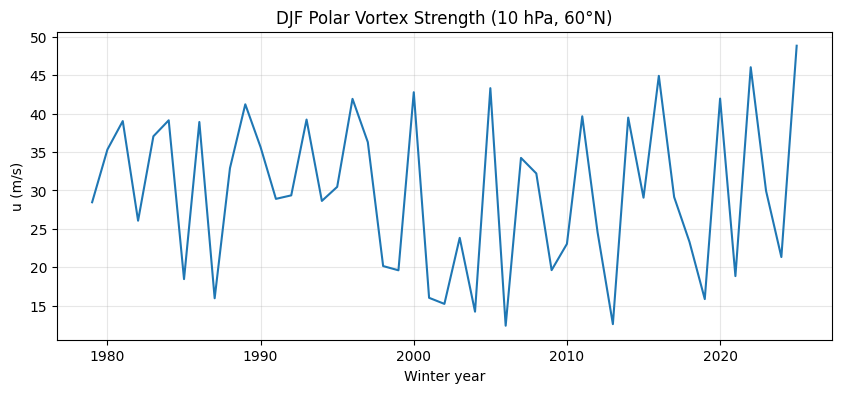

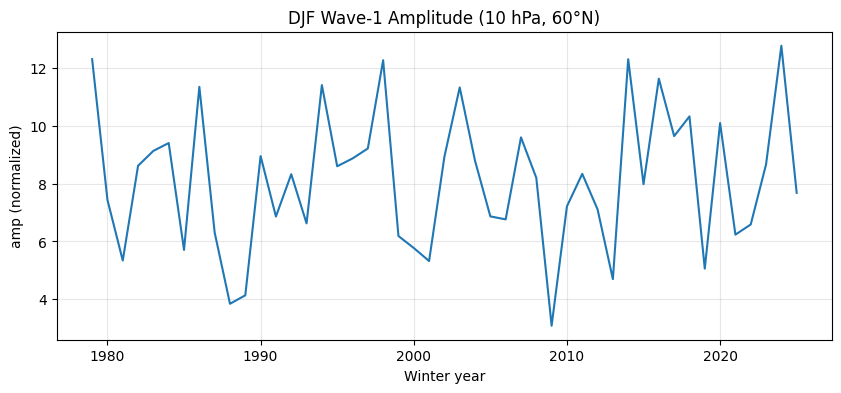

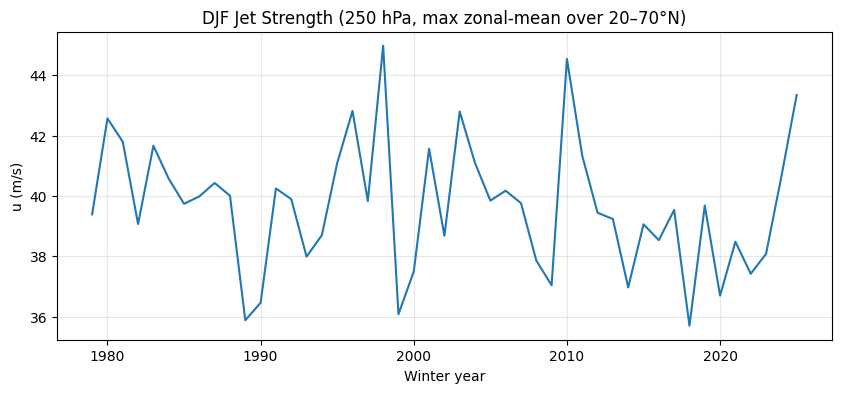

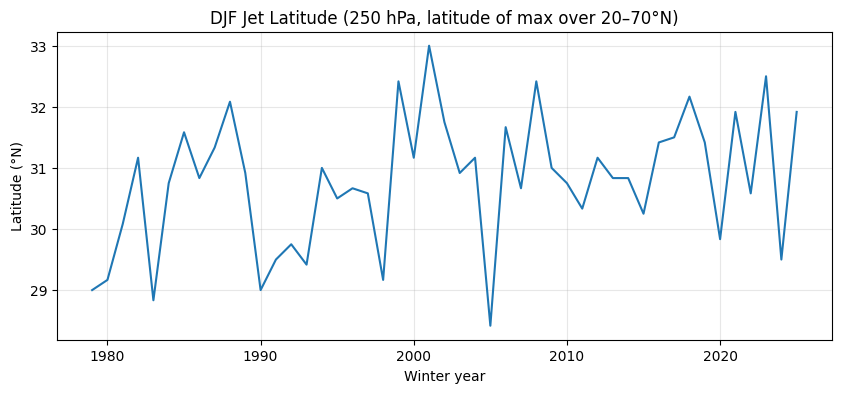

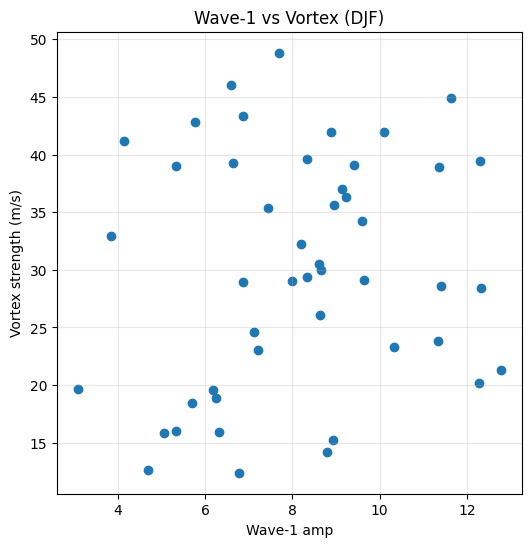

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

START_YEAR = 1979
END_YEAR   = 2025

def wave1_amp_from_lon(arr):
    arr = np.asarray(arr)
    if arr.ndim != 1 or arr.size < 8 or not np.isfinite(arr).all():
        return np.nan
    arr = arr - arr.mean()
    N = arr.size
    fft = np.fft.fft(arr)
    return float(np.abs(fft[1]) / N)

# Load both datasets
ds10  = xr.open_dataset("era5_u10_monthly_1979_2025.nc")
ds250 = xr.open_dataset("era5_u250_monthly_1979_2025.nc")

# standardize names
def standardize(ds):
    if "valid_time" in ds.dims: ds = ds.rename({"valid_time":"time"})
    if "latitude" in ds.coords and ds.latitude.values[0] > ds.latitude.values[-1]:
        ds = ds.sortby("latitude")
    # find u variable
    uvar = "u" if "u" in ds.data_vars else list(ds.data_vars)[0]
    return ds.rename({uvar:"u"})

ds10 = standardize(ds10)
ds250 = standardize(ds250)

# keep DJF months only
ds10_djf  = ds10.sel(time=ds10.time.dt.month.isin([12,1,2]))
ds250_djf = ds250.sel(time=ds250.time.dt.month.isin([12,1,2]))

rows = []

for t in ds10_djf.time.values:
    dt = pd.to_datetime(t)
    winter_year = dt.year + 1 if dt.month == 12 else dt.year
    if winter_year < START_YEAR or winter_year > END_YEAR:
        continue

    # ---------- 10 hPa vortex + wave1 ----------
    u10 = ds10_djf["u"].sel(time=t)
    u10_zm = u10.mean("longitude")
    vortex = float(u10_zm.sel(latitude=60, method="nearest"))

    u10_60 = u10.sel(latitude=60, method="nearest").squeeze()
    wave1 = wave1_amp_from_lon(u10_60.values)

    # ---------- 250 hPa jet metrics ----------
    u250 = ds250_djf["u"].sel(time=t)
    u250_zm = u250.mean("longitude")
    mid = u250_zm.sel(latitude=slice(20,70))

    jet_strength = float(mid.max())
    lat_vals = mid.latitude.values
    imax = int(np.nanargmax(mid.values))
    jet_lat = float(lat_vals[imax])

    rows.append({
        "winter_year": winter_year,
        "vortex_strength": vortex,
        "wave1_amp": wave1,
        "jet_strength": jet_strength,
        "jet_lat": jet_lat
    })

df = pd.DataFrame(rows)

# DJF mean per winter
djf = df.groupby("winter_year", as_index=False).mean()

# --- Trends per decade
def trend_per_decade(x, y):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(y)
    if m.sum() < 5: return np.nan
    a, b = np.polyfit(x[m], y[m], 1)
    return float(a*10)

print("Vortex trend (m/s/dec):", trend_per_decade(djf.winter_year, djf.vortex_strength))
print("Wave1 trend (units/dec):", trend_per_decade(djf.winter_year, djf.wave1_amp))
print("Jet strength trend (m/s/dec):", trend_per_decade(djf.winter_year, djf.jet_strength))
print("Jet latitude trend (deg/dec):", trend_per_decade(djf.winter_year, djf.jet_lat))

# --- Correlations
def corr(a,b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.corrcoef(np.asarray(a)[m], np.asarray(b)[m])[0,1])

print("Corr(vortex, wave1):", corr(djf.vortex_strength, djf.wave1_amp))
print("Corr(jet_strength, wave1):", corr(djf.jet_strength, djf.wave1_amp))
print("Corr(jet_lat, vortex):", corr(djf.jet_lat, djf.vortex_strength))

# --- Plots
plt.figure(figsize=(10,4))
plt.plot(djf.winter_year, djf.vortex_strength)
plt.title("DJF Polar Vortex Strength (10 hPa, 60°N)")
plt.xlabel("Winter year"); plt.ylabel("u (m/s)"); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(djf.winter_year, djf.wave1_amp)
plt.title("DJF Wave-1 Amplitude (10 hPa, 60°N)")
plt.xlabel("Winter year"); plt.ylabel("amp (normalized)"); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(djf.winter_year, djf.jet_strength)
plt.title("DJF Jet Strength (250 hPa, max zonal-mean over 20–70°N)")
plt.xlabel("Winter year"); plt.ylabel("u (m/s)"); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(djf.winter_year, djf.jet_lat)
plt.title("DJF Jet Latitude (250 hPa, latitude of max over 20–70°N)")-
plt.xlabel("Winter year"); plt.ylabel("Latitude (°N)"); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(djf.wave1_amp, djf.vortex_strength)
plt.title("Wave-1 vs Vortex (DJF)")
plt.xlabel("Wave-1 amp"); plt.ylabel("Vortex strength (m/s)")
plt.grid(alpha=0.3)
plt.show()